In [2]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions


level = 49
bound =500
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print(expansion[:20])

[(1, 1), (2, 1), (3, 0), (4, -1), (5, 0), (6, 0), (7, 0), (8, -3), (9, -3), (10, 0), (11, 4), (12, 0), (13, 0), (14, 0), (15, 0), (16, -1), (17, 0), (18, -3), (19, 0), (20, 0)]


In [4]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 49
bound =500
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run11april26no11.txt', 'wb') as wfile:
    pickle.dump(expansion, wfile) 
    
with open('/Users/barrybrent/data2/run11april26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 49a1
(1, 1)
(2, 1)
(3, -2)
(4, -3)
(5, 6)
(6, -2)
(7, -6)
(8, -19)
(9, 7)
(10, 16)
(11, 12)
(12, -66)
(13, 66)
(14, 36)
(15, -102)
(16, -115)
(17, 256)
(18, -65)
(19, -132)
(20, -108)
(21, 432)
(22, -54)
(23, -252)
(24, -754)
(25, 1581)
(26, 92)
(27, -2018)
(28, -640)
(29, 5656)
(30, -3272)
(31, -4680)
(32, 2573)
(33, 10140)
(34, -10182)
(35, -6406)
(36, 4083)
(37, 26752)
(38, -24566)
(39, -28758)
(40, 25316)
(41, 82780)
(42, -113640)
(43, -57060)
(44, 144614)
(45, 128742)
(46, -353164)
(47, 3432)
(48, 356654)
(49, 189232)
(50, -853009)
(51, 61810)
(52, 1011488)
(53, 437410)
(54, -2704628)
(55, 675692)
(56, 3501248)
(57, -580794)
(58, -7591706)
(59, 5063440)
(60, 8164044)
(61, -5801770)
(62, -16655524)
(63, 17168130)
(64, 17374093)
(65, -19379354)
(66, -41322756)
(67, 54733842)
(68, 44534846)
(69, -77228712)
(70, -96702044)
(71, 194461546)
(72, 70912307)
(73, -272951452)
(74, -145642914)
(75, 573911598)
(76, 10162470)
(77, -757951420)
(78, -145869076)
(79, 1554574878)
(80, -2900

1 0.000152281920115153
2 0.00021176735560099285
3 0.00023068189620971679
4 0.0002490997314453125
5 0.00027599732081095375
6 0.00031099716822306317
7 0.00033801794052124023
8 0.0003695130348205566
9 0.0004175821940104167
10 0.00047820011774698894
11 0.0005386511484781902
12 0.0006083170572916667
13 0.0006992340087890625
14 0.0007969339688618978
15 0.000995031992594401
16 0.0011519670486450195
17 0.0013022661209106446
18 0.0014907479286193847
19 0.0016777634620666504
20 0.001855015754699707
21 0.002039353052775065
22 0.002302364508310954
23 0.002528246243794759
24 0.0028013308842976888
25 0.003090981642405192
26 0.003635096549987793
27 0.004189431667327881
28 0.00464783509572347
29 0.00516666571299235
30 0.0056765993436177576
31 0.006207899252573649
32 0.006786851088205973
33 0.00734705130259196
34 0.008032699426015219
35 0.008664631843566894
36 0.009399763743082682
37 0.01011201540629069
38 0.010984551906585694
39 0.011884947617848715
40 0.012814350922902425
41 0.013736200332641602
42 0

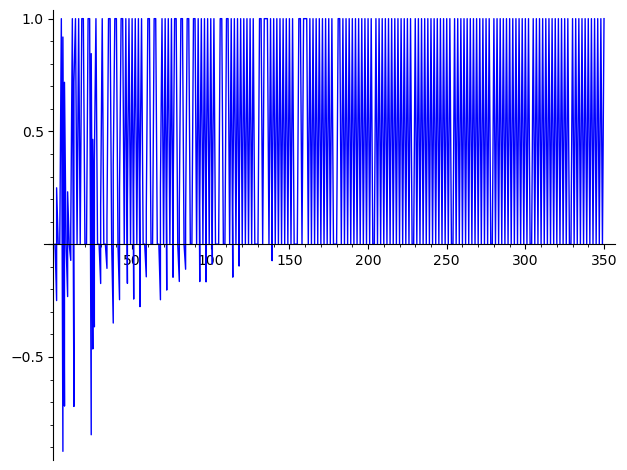

MINIMUM MODULI


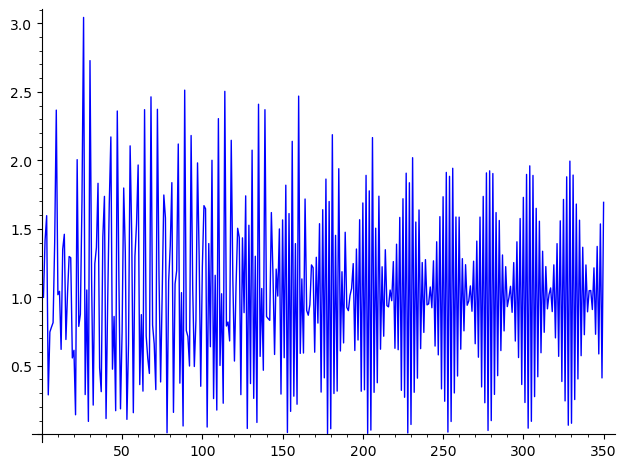

In [6]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time
start=time.time()


with open('/Users/barrybrent/data2/run11april26no12.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
args_list=[]

dets=[]

for n in range(1, 351):
    print(n,(time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    
    minn = min(aar)  
    mins_list.append((n,minn))

    for root in roots:
        if abs(root)==minn:
            theta=root.arg()
            args_list.append((n,theta/pi))


p = list_plot(args_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI ARGUMENTS")
p.show()

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run11april26no13.txt', 'wb') as wfile:
    pickle.dump(args_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run11april26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run11april26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
